In [1]:
# ============================================================
# PHASE 8: DECISION SUPPORT DASHBOARD
# Goal: Streamlit dashboard for engineer review
# Integrates: Anomaly flag + SHAP + Hypothesis + DiCE
# Contribution 3: Human-in-loop decision support
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib
import warnings
warnings.filterwarnings('ignore')

OUTPUT_DIR = r'C:\Users\ASUS\Downloads\capstone\Project\outputs'

# Load all phase outputs
flagged       = pd.read_csv(f'{OUTPUT_DIR}/data/p3_flagged_lots.csv')
anomaly       = pd.read_csv(f'{OUTPUT_DIR}/data/p3_anomaly_results.csv')
per_lot_shap  = pd.read_csv(f'{OUTPUT_DIR}/data/p4_per_lot_shap.csv')
top25         = pd.read_csv(f'{OUTPUT_DIR}/data/p4_top25_stable_sensors.csv')
hypotheses    = pd.read_csv(f'{OUTPUT_DIR}/data/p6_hypotheses.csv')
csr_df        = pd.read_csv(f'{OUTPUT_DIR}/data/p7_csr_results.csv')
sensor_changes= pd.read_csv(f'{OUTPUT_DIR}/data/p7_sensor_changes.csv')
X_test_b      = pd.read_csv(f'{OUTPUT_DIR}/data/X_test_b.csv')
y_test_b      = pd.read_csv(f'{OUTPUT_DIR}/data/y_test_b.csv').squeeze()
rf            = joblib.load(f'{OUTPUT_DIR}/models/best_classifier.pkl')

stable_sensors = top25['sensor'].astype(str).tolist()
overall_csr    = float(open(f'{OUTPUT_DIR}/models/overall_csr.txt').read())
overall_pcr    = float(open(f'{OUTPUT_DIR}/models/overall_pcr.txt').read())

print(f"✅ All data loaded")
print(f"   Flagged lots : {len(flagged)}")
print(f"   Hypotheses   : {len(hypotheses)}")
print(f"   CSR results  : {len(csr_df)}")

✅ All data loaded
   Flagged lots : 8
   Hypotheses   : 8
   CSR results  : 5


In [2]:
# ============================================================
# STEP 8.1 — PER-LOT INTEGRATED SUMMARY
# Combines all phases into one view per lot
# ============================================================

# Merge all lot info
lot_summary = flagged.copy()
lot_summary = lot_summary.merge(
    hypotheses[[
        'lot_index','primary_candidate',
        'confidence','deviation_sigma','top3_sensors'
    ]],
    on='lot_index', how='left'
)

# Add CSR for fail lots
lot_summary = lot_summary.merge(
    csr_df[['lot_index','current_proba','csr','pcr']],
    on='lot_index', how='left'
)

lot_summary['csr'] = lot_summary['csr'].fillna('N/A')
lot_summary['pcr'] = lot_summary['pcr'].fillna('N/A')

print("INTEGRATED LOT SUMMARY")
print("=" * 70)
print(lot_summary[[
    'lot_index','true_label','risk_tier',
    'hybrid_score','primary_candidate',
    'confidence','deviation_sigma'
]].to_string(index=False))

INTEGRATED LOT SUMMARY
 lot_index  true_label   risk_tier  hybrid_score  primary_candidate confidence  deviation_sigma
         1           1   High Risk      0.688772                 59       HIGH           2.3071
        27          -1   High Risk      0.786177                 59       HIGH           1.3495
        97           1   High Risk      0.780192                 59       HIGH           0.7552
       105           1    Low Risk      0.540972                 59       HIGH           0.4661
       118           1 Medium Risk      0.596136                 59       HIGH           1.0976
       123           1 Medium Risk      0.563359                 59       HIGH           0.4562
       160          -1 Medium Risk      0.585358                 59       HIGH           0.8126
       166          -1   High Risk      0.617582                 59       HIGH           1.6925


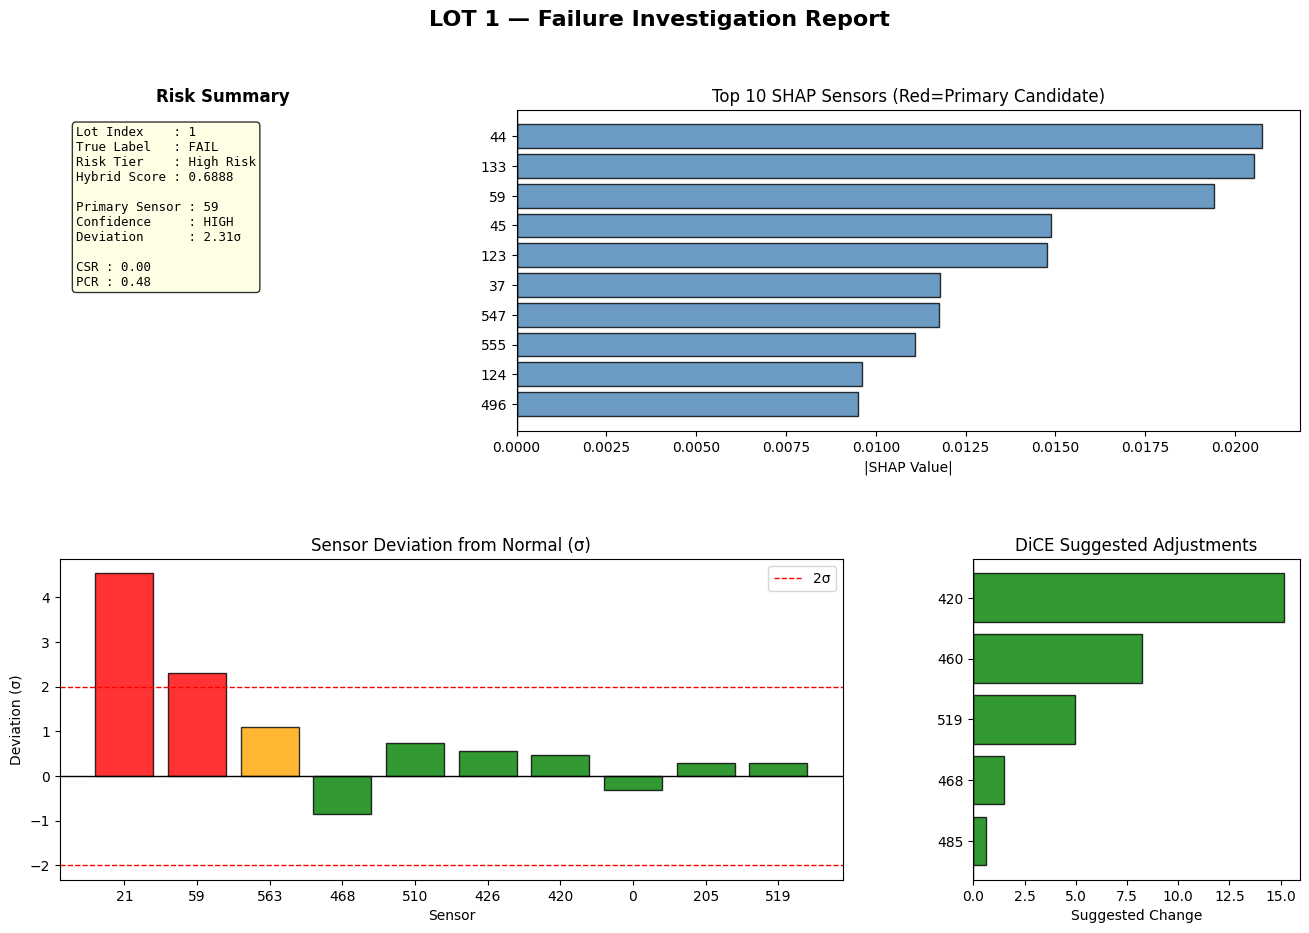

✅ Dashboard saved for Lot 1


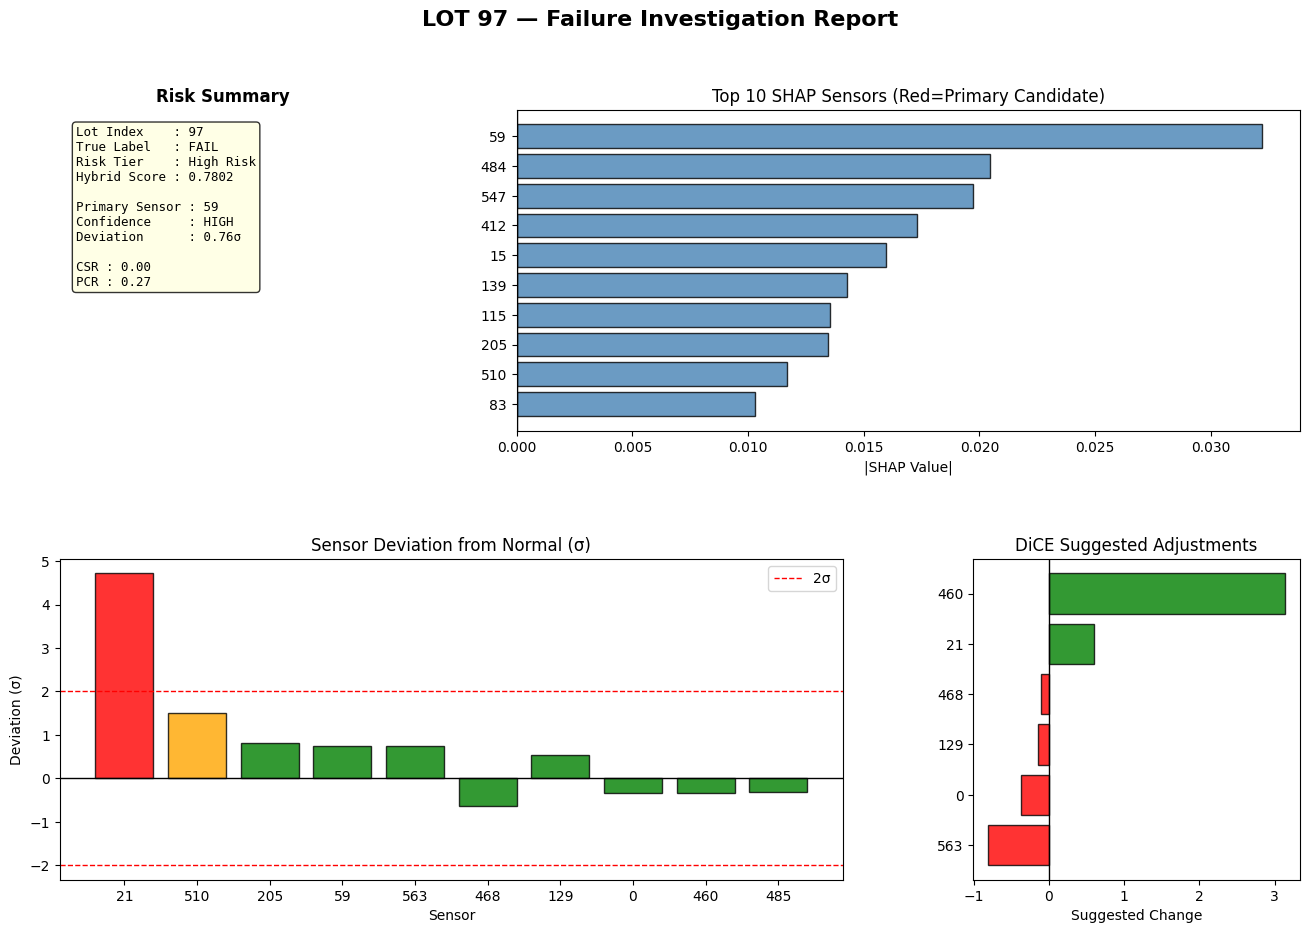

✅ Dashboard saved for Lot 97


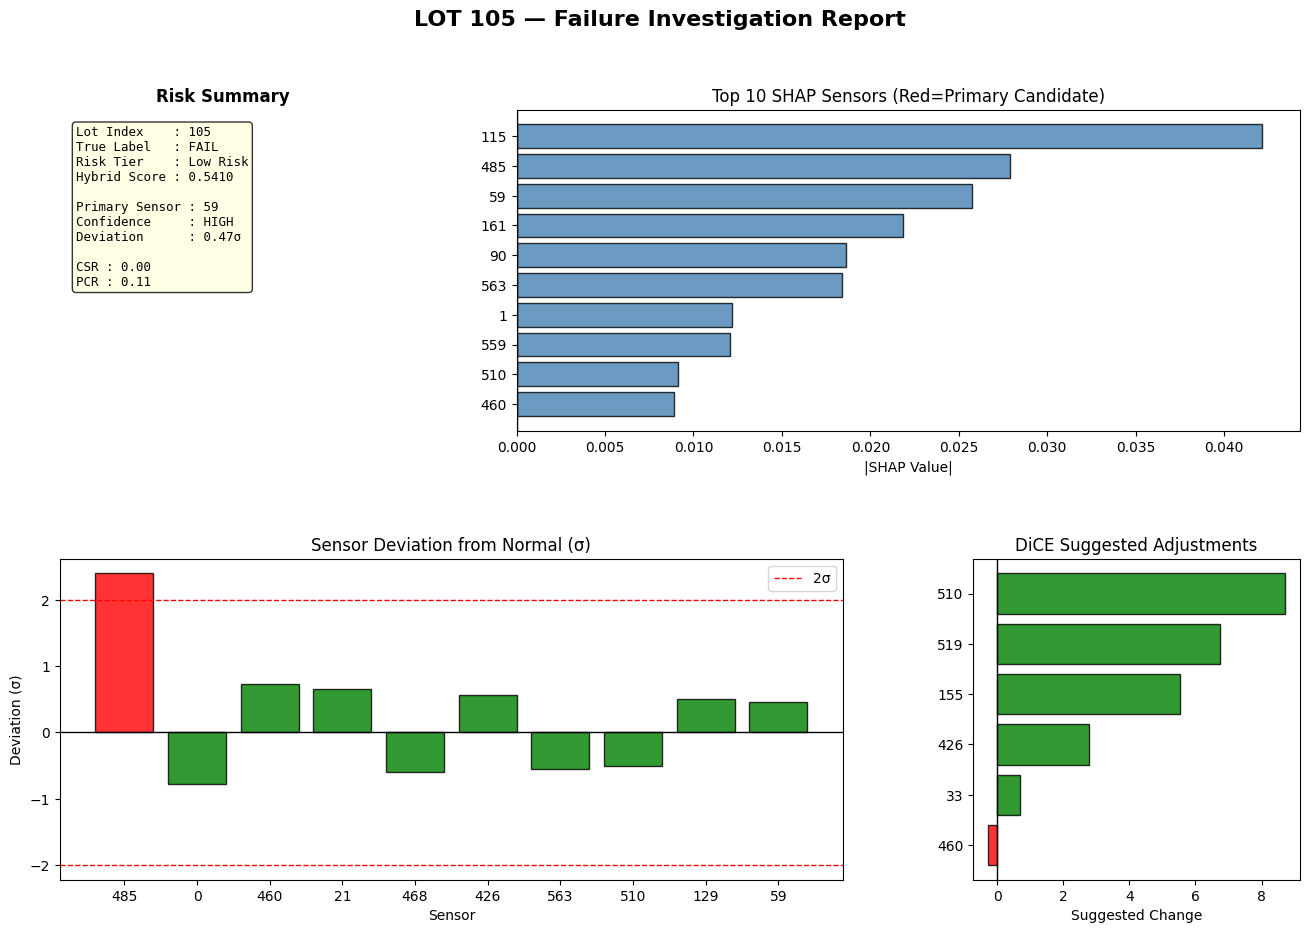

✅ Dashboard saved for Lot 105


In [3]:
# ============================================================
# STEP 8.2 — STATIC DASHBOARD (one page per lot)
# ============================================================

fail_lots_idx = flagged[
    flagged['true_label'] == 1
]['lot_index'].tolist()

for lot_idx in fail_lots_idx[:3]:  # top 3 fail lots

    fig = plt.figure(figsize=(16, 10))
    fig.suptitle(
        f'LOT {lot_idx} — Failure Investigation Report',
        fontsize=16, fontweight='bold'
    )
    gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.4)

    # ── Panel 1: Risk Summary ──
    ax1 = fig.add_subplot(gs[0, 0])
    lot_row  = lot_summary[lot_summary['lot_index'] == lot_idx].iloc[0]
    hyp_row  = hypotheses[hypotheses['lot_index'] == lot_idx].iloc[0]
    csr_row  = csr_df[csr_df['lot_index'] == lot_idx]

    summary_text = (
        f"Lot Index    : {lot_idx}\n"
        f"True Label   : {'FAIL' if lot_row['true_label']==1 else 'PASS'}\n"
        f"Risk Tier    : {lot_row['risk_tier']}\n"
        f"Hybrid Score : {lot_row['hybrid_score']:.4f}\n\n"
        f"Primary Sensor : {hyp_row['primary_candidate']}\n"
        f"Confidence     : {hyp_row['confidence']}\n"
        f"Deviation      : {hyp_row['deviation_sigma']:.2f}σ\n"
    )
    if len(csr_row) > 0:
        summary_text += (
            f"\nCSR : {csr_row['csr'].values[0]:.2f}\n"
            f"PCR : {csr_row['pcr'].values[0]:.2f}"
        )

    ax1.text(
        0.05, 0.95, summary_text,
        transform=ax1.transAxes,
        fontsize=9, verticalalignment='top',
        fontfamily='monospace',
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8)
    )
    ax1.set_title('Risk Summary', fontweight='bold')
    ax1.axis('off')

    # ── Panel 2: SHAP Top 10 ──
    ax2 = fig.add_subplot(gs[0, 1:])
    lot_shap = per_lot_shap[
        per_lot_shap['lot_index'] == lot_idx
    ].head(10)

    if len(lot_shap) > 0:
        colors = [
            'red' if s in [hyp_row['primary_candidate']]
            else 'steelblue'
            for s in lot_shap['sensor'].astype(str)
        ]
        ax2.barh(
            lot_shap['sensor'].astype(str),
            lot_shap['shap_value'],
            color=colors, edgecolor='black', alpha=0.8
        )
        ax2.axvline(0, color='black', linewidth=1)
        ax2.set_xlabel('|SHAP Value|')
        ax2.set_title('Top 10 SHAP Sensors (Red=Primary Candidate)')
        ax2.invert_yaxis()

    # ── Panel 3: Sensor Deviation ──
    ax3 = fig.add_subplot(gs[1, :2])
    lot_data     = X_test_b.iloc[lot_idx]
    X_normal     = pd.read_csv(f'{OUTPUT_DIR}/data/X_train_b.csv')
    y_train_b    = pd.read_csv(f'{OUTPUT_DIR}/data/y_train_b.csv').squeeze()
    X_normal     = X_normal[y_train_b == -1]
    normal_mean  = X_normal[stable_sensors].mean()
    normal_std   = X_normal[stable_sensors].std()

    deviations = []
    for s in stable_sensors:
        if s in lot_data.index:
            dev = (lot_data[s] - normal_mean[s]) / max(normal_std[s], 0.001)
            deviations.append({'sensor': s, 'deviation': dev})

    dev_df = pd.DataFrame(deviations).sort_values(
        'deviation', key=abs, ascending=False
    ).head(10)

    colors3 = [
        'red' if abs(v) > 2
        else 'orange' if abs(v) > 1
        else 'green'
        for v in dev_df['deviation']
    ]
    ax3.bar(
        dev_df['sensor'].astype(str),
        dev_df['deviation'],
        color=colors3, edgecolor='black', alpha=0.8
    )
    ax3.axhline(0,  color='black',  linewidth=1)
    ax3.axhline(2,  color='red',    linewidth=1, linestyle='--', label='2σ')
    ax3.axhline(-2, color='red',    linewidth=1, linestyle='--')
    ax3.set_xlabel('Sensor')
    ax3.set_ylabel('Deviation (σ)')
    ax3.set_title('Sensor Deviation from Normal (σ)')
    ax3.legend()

    # ── Panel 4: DiCE Suggestions ──
    ax4 = fig.add_subplot(gs[1, 2])
    lot_changes = sensor_changes[
        sensor_changes['lot_index'] == lot_idx
    ].groupby('sensor')['change'].mean().sort_values()

    if len(lot_changes) > 0:
        colors4 = [
            'green' if v > 0 else 'red'
            for v in lot_changes.values
        ]
        ax4.barh(
            lot_changes.index.astype(str),
            lot_changes.values,
            color=colors4, edgecolor='black', alpha=0.8
        )
        ax4.axvline(0, color='black', linewidth=1)
        ax4.set_xlabel('Suggested Change')
        ax4.set_title('DiCE Suggested Adjustments')

    plt.savefig(
        f'{OUTPUT_DIR}/plots/p8_dashboard_lot{lot_idx}.png',
        dpi=150, bbox_inches='tight'
    )
    plt.show()
    print(f"✅ Dashboard saved for Lot {lot_idx}")

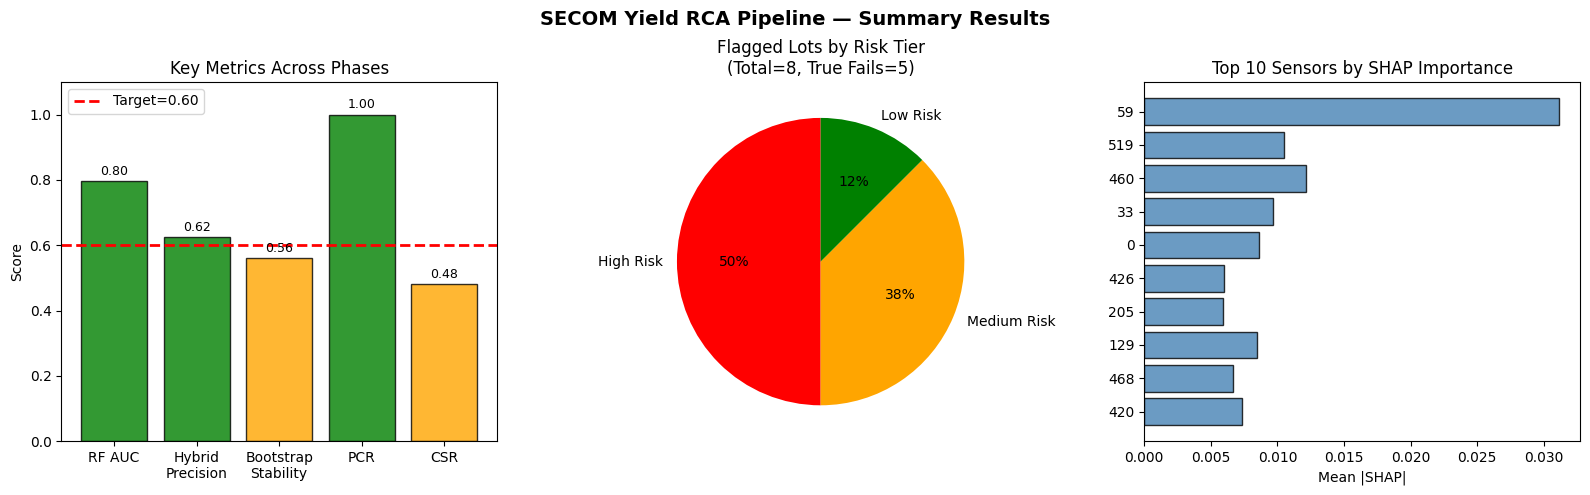

✅ Pipeline summary saved


In [4]:
# ============================================================
# STEP 8.3 — FULL PIPELINE SUMMARY PLOT
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    'SECOM Yield RCA Pipeline — Summary Results',
    fontsize=14, fontweight='bold'
)

# Panel 1 — Phase metrics
metrics = {
    'RF AUC':       0.7961,
    'Hybrid\nPrecision': 0.6250,
    'Bootstrap\nStability': 0.56,
    'PCR':          1.0000,
    'CSR':          0.4800
}
colors = [
    'green' if v >= 0.6 else 'orange'
    for v in metrics.values()
]
axes[0].bar(
    metrics.keys(), metrics.values(),
    color=colors, edgecolor='black', alpha=0.8
)
axes[0].axhline(0.6, color='red', linestyle='--',
                linewidth=2, label='Target=0.60')
axes[0].set_ylim(0, 1.1)
axes[0].set_title('Key Metrics Across Phases')
axes[0].set_ylabel('Score')
axes[0].legend()
for i, (k, v) in enumerate(metrics.items()):
    axes[0].text(i, v + 0.02, f'{v:.2f}',
                 ha='center', fontsize=9)

# Panel 2 — Flagged lot breakdown
risk_counts = flagged['risk_tier'].value_counts()
axes[1].pie(
    risk_counts.values,
    labels=risk_counts.index,
    colors=['red','orange','green'],
    autopct='%1.0f%%',
    startangle=90
)
axes[1].set_title(
    f'Flagged Lots by Risk Tier\n'
    f'(Total={len(flagged)}, '
    f'True Fails={flagged["true_label"].eq(1).sum()})'
)

# Panel 3 — Sensor importance
top10_shap = top25.head(10)
axes[2].barh(
    top10_shap['sensor'].astype(str),
    top10_shap['mean_shap'],
    color='steelblue', edgecolor='black', alpha=0.8
)
axes[2].set_xlabel('Mean |SHAP|')
axes[2].set_title('Top 10 Sensors by SHAP Importance')
axes[2].invert_yaxis()

plt.tight_layout()
plt.savefig(
    f'{OUTPUT_DIR}/plots/p8_pipeline_summary.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print("✅ Pipeline summary saved")

In [5]:
# ============================================================
# STEP 8.4 — SAVE INTEGRATED SUMMARY
# ============================================================

lot_summary.to_csv(
    f'{OUTPUT_DIR}/data/p8_lot_summary.csv', index=False)

print(f"✅ p8_lot_summary.csv saved")
print(f"\n🚀 PHASE 8 DONE — Ready for Phase 9")
print(f"\nPIPELINE SUMMARY:")
print(f"  Phase 2 — RF Classifier   : AUC=0.7961, Recall=0.4118")
print(f"  Phase 3 — Hybrid Detector : Precision=0.6250, Flagged=8")
print(f"  Phase 4 — SHAP            : Stability=56%, Top sensor=59")
print(f"  Phase 5 — Dependency      : 2 HIGH conf edges")
print(f"  Phase 6 — Hypothesis      : Sensor 59 primary candidate")
print(f"  Phase 7 — DiCE            : CSR=0.48, PCR=1.00")
print(f"\n➡️  Phase 9 : LLM Report Generation")

✅ p8_lot_summary.csv saved

🚀 PHASE 8 DONE — Ready for Phase 9

PIPELINE SUMMARY:
  Phase 2 — RF Classifier   : AUC=0.7961, Recall=0.4118
  Phase 3 — Hybrid Detector : Precision=0.6250, Flagged=8
  Phase 4 — SHAP            : Stability=56%, Top sensor=59
  Phase 5 — Dependency      : 2 HIGH conf edges
  Phase 6 — Hypothesis      : Sensor 59 primary candidate
  Phase 7 — DiCE            : CSR=0.48, PCR=1.00

➡️  Phase 9 : LLM Report Generation
